# Phase 2 Data Processing & Quality Control (QC)

## Load Data via SQL

In [1]:
import sqlite3
import pandas as pd
import scanpy as sc
import anndata as ad
import warnings
warnings.filterwarnings('ignore')

# 1. Query the SQLite database for our target cohort
conn = sqlite3.connect("data/als_microglia.db")
query = "SELECT gsm_id, donor_id, tissue, h5_filename FROM cohort_metadata WHERE tissue = 'SC' AND batch_protocol = 'Single-Run';"
cohort_df = pd.read_sql_query(query, conn)
conn.close()

# 2. Loop through files and load them into a list of AnnData objects
adata_list = []
for index, row in cohort_df.iterrows():
    h5_path = f"data/raw/{row['h5_filename']}"
    print(f"Loading {row['gsm_id']} ({row['donor_id']} {row['tissue']}) from {h5_path}...")
    
    # Read 10x H5 format
    sample_adata = sc.read_10x_h5(h5_path)
    sample_adata.var_names_make_unique()
    
    # Inject metadata from our database straight into the cell metadata (.obs)
    sample_adata.obs['gsm_id'] = row['gsm_id']
    sample_adata.obs['donor_id'] = row['donor_id']
    sample_adata.obs['tissue'] = row['tissue']
    
    adata_list.append(sample_adata)

# 3. Concatenate all 5 samples into a single unified workspace
adata = ad.concat(adata_list, join="outer", label="batch", merge="unique")
adata.X = adata.X.tocsr() # Ensure matrix is in optimized Compressed Sparse Row format

print(f"\nUnified Object Shape: {adata.shape[0]} cells x {adata.shape[1]} genes")

Loading GSM6186106 (ALS4 SC) from data/raw/GSM6186106_MA004_filtered_feature_bc_matrix.h5...
Loading GSM6186110 (ALS1 SC) from data/raw/GSM6186110_PM039_filtered_feature_bc_matrix.h5...
Loading GSM6186112 (ALS2 SC) from data/raw/GSM6186112_PM041_filtered_feature_bc_matrix.h5...
Loading GSM6186115 (ALS3 SC) from data/raw/GSM6186115_PM045_filtered_feature_bc_matrix.h5...
Loading GSM6186120 (ALS5 SC) from data/raw/GSM6186120_PM052_filtered_feature_bc_matrix.h5...

Unified Object Shape: 15042 cells x 27984 genes


## Gene & Mitochondrial Filtering

In [2]:
# 1. Enforce rigorous gene filtering standard
sc.pp.filter_genes(adata, min_cells=3)

# 2. Identify mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# 3. Calculate advanced single-cell QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Let's inspect the distribution of our cells before pulling the trigger
print("QC Metrics computed. Sample data columns added to cell metadata (.obs):")
print(list(adata.obs.columns))

QC Metrics computed. Sample data columns added to cell metadata (.obs):
['gsm_id', 'donor_id', 'tissue', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


## Visualize Thresholds to Set the Line

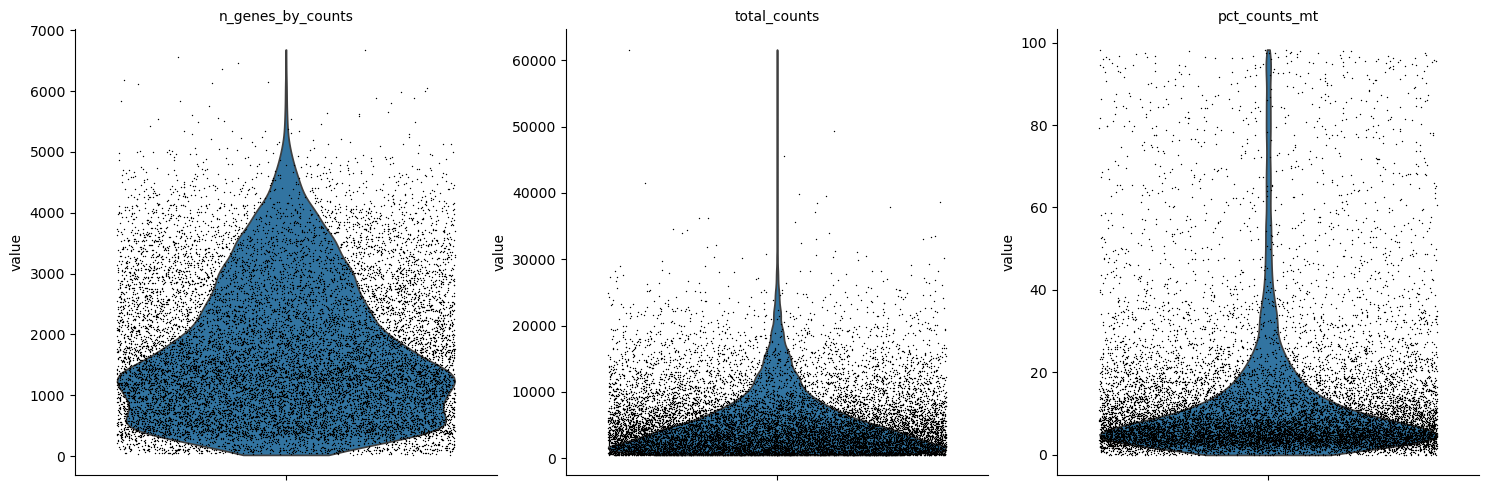


Post-filtering Object Shape: 11447 high-quality cells remaining.


In [3]:
import scanpy as sc

# 1. Plot QC metrics cleanly using the correct multi_panel argument
sc.pl.violin(
    adata, 
    keys=['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
    multi_panel=True, 
    jitter=0.4
)

# 2. Apply the rigorous human neuro-QC thresholds
max_mito = 15.0   # Drop dead cells with > 15% mitochondrial reads
min_genes = 200   # Drop empty droplets with fewer than 200 unique genes
max_genes = 6000  # Drop extreme multiplexed doublets

adata = adata[(adata.obs['pct_counts_mt'] < max_mito) & 
              (adata.obs['n_genes_by_counts'] > min_genes) & 
              (adata.obs['n_genes_by_counts'] < max_genes), :]

print(f"\nPost-filtering Object Shape: {adata.shape[0]} high-quality cells remaining.")

## Programmatic Doublet Removal (Scrublet Layer)

In [4]:
#!pip install scikit-image

In [5]:
import anndata as ad
import scanpy as sc

filtered_batches = []

# Loop through each batch to simulate doublet double-captures independently
for batch_id in adata.obs['batch'].unique():
    batch_data = adata[adata.obs['batch'] == batch_id].copy()
    
    # Execute scanpy's native scrublet wrapper now that skimage is installed
    sc.pp.scrublet(batch_data, verbose=False)
    filtered_batches.append(batch_data)

# Re-concatenate the cleared cell matrices
adata = ad.concat(filtered_batches, merge="unique")

# Drop the predicted doublets from our workspace
adata = adata[adata.obs['predicted_doublet'] == False, :]

print("\n---------------------------------------------------------------------------")
print(f"🎉 Phase 2 Complete! Cleaned Data Shape: {adata.shape[0]} pristine cells x {adata.shape[1]} genes.")
print("---------------------------------------------------------------------------")


---------------------------------------------------------------------------
🎉 Phase 2 Complete! Cleaned Data Shape: 11371 pristine cells x 19081 genes.
---------------------------------------------------------------------------


In [6]:
#why not use all 21 data matrices

# Phase 3 - Dimensionality Reduction & Feature Selection

## Step 1: Log-Normalization & Feature Selection (HVGs)

--- INITIALIZING PHASE 3 FEATURE SELECTION ---


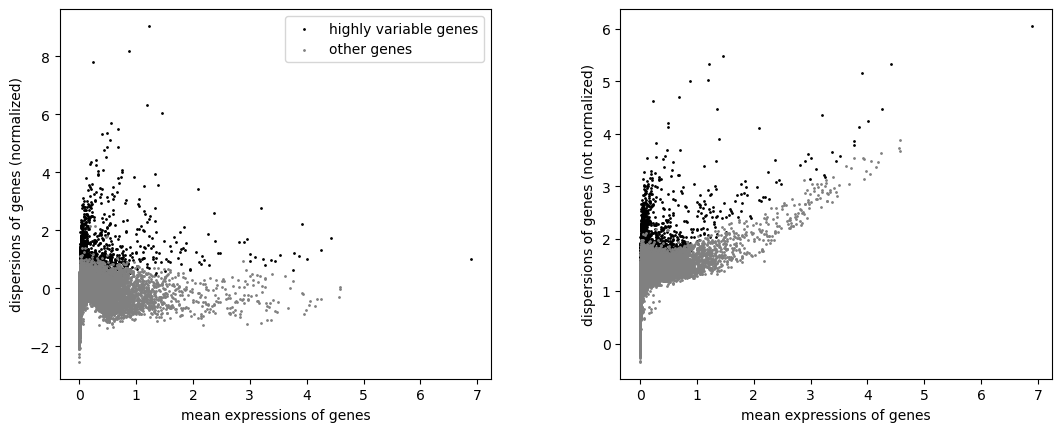

🧬 Feature Selection Complete. Isolated the top 2000 Highly Variable Genes.


In [7]:
import scanpy as sc
import pandas as pd
import numpy as np

print("--- INITIALIZING PHASE 3 FEATURE SELECTION ---")

# 1. Freeze raw counts matrix in .raw slot for downstream differential expression (Phase 5)
adata.raw = adata.copy()

# 2. Normalize every cell to a total sum of 10,000 counts
sc.pp.normalize_total(adata, target_sum=1e4)

# 3. Log-transform the matrix: X = log(X + 1)
sc.pp.log1p(adata)

# 4. Isolate the top 2,000 genes driving true variance, adjusting for batch effects
sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=2000, 
    flavor='seurat', 
    batch_key='batch'
)

# 5. Visualize the variance-to-expression plot
sc.pl.highly_variable_genes(adata)

# Print out a verification metric
hvg_count = adata.var['highly_variable'].sum()
print(f"🧬 Feature Selection Complete. Isolated the top {hvg_count} Highly Variable Genes.")

## Step 2: Scaling and PCA Computation

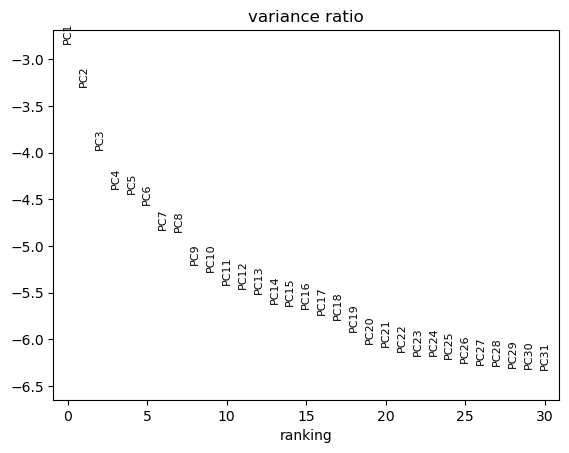

In [8]:
# 1. Scale the data (cap extreme values at 10 to keep outliers from swinging the PCA)
sc.pp.scale(adata, max_value=10)

# 2. Compute Principal Component Analysis utilizing ONLY our isolated HVGs
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

# 3. Generate an "Elbow Plot" to evaluate eigenvalues/variance explained per PC axis
sc.pl.pca_variance_ratio(adata, n_pcs=30, log=True)

## Step 3: Extracting and Evaluating Gene Loadings (varm['PCs'])

In [9]:
# 1. Extract the raw structural loadings from the AnnData object
pca_loadings = pd.DataFrame(
    adata.varm['PCs'], 
    index=adata.var_names, 
    columns=[f'PC{i+1}' for i in range(adata.varm['PCs'].shape[1])]
)

print("--- TOP GENE LOADINGS DRIVING PC1 ---")
# Genes driving variation in the positive direction of PC1
top_pc1_positive = pca_loadings['PC1'].sort_values(ascending=False).head(10)
print("\nTop 10 Positive Driving Genes (PC1):")
print(top_pc1_positive)

print("\n--- TOP GENE LOADINGS DRIVING PC2 ---")
# Genes driving variation in the positive direction of PC2
top_pc2_positive = pca_loadings['PC2'].sort_values(ascending=False).head(10)
print("\nTop 10 Positive Driving Genes (PC2):")
print(top_pc2_positive)

--- TOP GENE LOADINGS DRIVING PC1 ---

Top 10 Positive Driving Genes (PC1):
PCDH9     0.086214
NTM       0.085993
NOVA1     0.081360
NCAM1     0.078233
NFASC     0.077683
SCD5      0.075470
PTPRZ1    0.074583
GPM6A     0.073930
GRIA2     0.072642
LSAMP     0.071828
Name: PC1, dtype: float64

--- TOP GENE LOADINGS DRIVING PC2 ---

Top 10 Positive Driving Genes (PC2):
CCL5     0.131166
CD2      0.119223
IL32     0.118756
CD3E     0.118537
TRBC2    0.111743
CD3D     0.110911
TRAC     0.110854
ETS1     0.109338
CD52     0.107653
CCL4     0.107393
Name: PC2, dtype: float64


## Saving the State 

In [10]:
# Save the complete integrated state of your workspace
from pathlib import Path

# 1. Automatically create the directory structure if it doesn't exist
Path("data/processed").mkdir(parents=True, exist_ok=True)

# 2. Save the complete integrated state of your workspace
adata.write_h5ad("data/processed/als_spinal_cord_phase3_pca.h5ad")
print("🎉 Workspace state securely serialized to disk!")

🎉 Workspace state securely serialized to disk!


In [11]:
##